# Correlation
## Example 1: is the population of children related to the population of women in a NYS county?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

nys_pop = pd.read_csv("../09-advanced_data_operations/data/ny_county_pop.csv")

nys_pop.head()


,county,gender,child,adult,senior
0,Albany County,M,29296,99324,24568
1,Albany County,F,28137,102485,31564
2,Allegany County,M,4803,14536,4526
3,Allegany County,F,4541,13868,4753
4,Bronx County,M,177091,414274,79363


In [2]:
children_pop = nys_pop.groupby("county", as_index=False)['child'].sum()
women_pop = nys_pop[nys_pop['gender'] == "F"].drop(columns='gender').set_index("county")['adult'].rename("women").reset_index()

compare_df = pd.merge(left=children_pop, right=women_pop, how="outer", on="county").fillna(0)

compare_df

,county,child,women
0,Albany County,57433,102485
1,Allegany County,9344,13868
2,Bronx County,347363,459911
3,Broome County,38153,59659
4,Cattaraugus County,16836,21781
...,...,...,...
57,Washington County,11303,17535
58,Wayne County,19331,26414
59,Westchester County,214739,306495
60,Wyoming County,7477,10710


### Compute correlation

In [3]:
corr, p_value = pearsonr(compare_df["child"], compare_df["women"])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.9835521833854484
p-value: 2.6581420775270697e-46


Interpretation: children population has a very strong relationship with women population. And such relationship is statistical significant.

### Visual inspection

Text(1, 550000, 'corr=0.984\np_value=0.000')

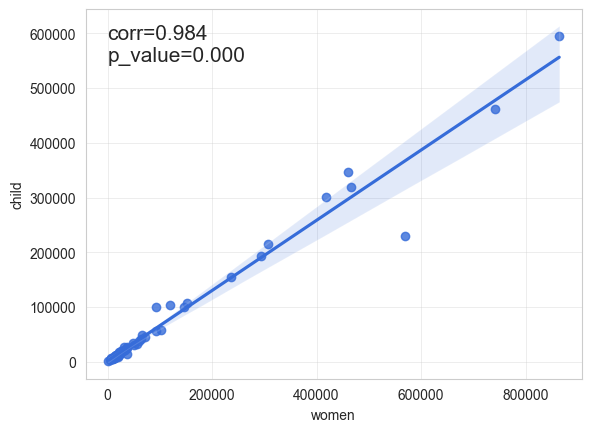

In [4]:
sns.set_style("whitegrid")
g=sns.regplot(data=compare_df, x="women", y="child")

g.text(x=1, y=550_000, s=f"{corr=:.3f}\n{p_value=:.3f}", fontsize=15)


## Example 2: is movie length related to rating?

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

df = pd.read_csv("../08-core_data_manipulation/data/IMDB Top 250 Movies.csv")

df.head()


,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000,28884504,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont"
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000,250341816,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola"
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000,1006234167,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer"
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000,47961919,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo"
4,5,12 Angry Men,1957,9.0,"Crime,Drama",Approved,1h 36m,Life Is In Their Hands -- Death Is On Their Mi...,350000,955,"Henry Fonda,Lee J. Cobb,Martin Balsam,John Fie...",Sidney Lumet,Reginald Rose


In [37]:
df['run_time_timedelta'] = pd.to_timedelta(df['run_time'], unit='m', errors='coerce')

df['run_time_mins'] = df['run_time_timedelta'].dt.total_seconds()/60
df['box_office'] = pd.to_numeric(df['box_office'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

clean_df = df.dropna(subset=['run_time_mins', 'box_office', "rating"])

In [39]:

corr, p_value = pearsonr(clean_df["run_time_mins"], clean_df["rating"])

print("Correlation:", corr)
print("p-value:", p_value)


Correlation: 0.24274925843219647
p-value: 0.0003170186240753854


Interpretation: The length of movie has a moderate and positive relationship with movie ratings.

### Visual inspection

Text(8.8, 225, 'corr=-0.439\np_value=0.000')

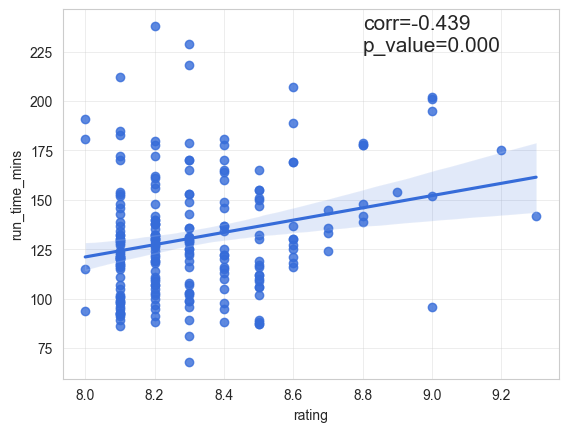

In [82]:
sns.set_style("whitegrid")
g=sns.regplot(data=clean_df, x="rating", y="run_time_mins")
g.text(x=8.8, y=225, s=f"{corr=:.3f}\n{p_value=:.3f}", fontsize=15)

## Example 3: is male-to-female ratio related to children population in NYS?

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

nys_pop = pd.read_csv("../09-advanced_data_operations/data/ny_county_pop.csv")

nys_pop.head()

children_pop = nys_pop.groupby("county", as_index=False)['child'].sum()

compare_df = pd.merge(left=children_pop, right=nys_pop.sort_values(by='gender').set_index("gender").groupby("county", as_index=False).agg(
    male_female_rate = ('adult', lambda x: x.iloc[1]*100/x.iloc[0])
), on="county", how="left")

compare_df


,county,child,male_female_rate
0,Albany County,57433,96.915646
1,Allegany County,9344,104.816845
2,Bronx County,347363,90.076993
3,Broome County,38153,101.498517
4,Cattaraugus County,16836,102.658280
...,...,...,...
57,Washington County,11303,110.219561
58,Wayne County,19331,102.192019
59,Westchester County,214739,97.563092
60,Wyoming County,7477,129.383754


In [78]:
# compute correlation

corr, p_value = pearsonr(compare_df["male_female_rate"], compare_df['child'])

print("Correlation:", corr)
print("p-value:", p_value)


Correlation: -0.4387155831928259
p-value: 0.0003613657336290736


Text(400000, 120, 'corr=-0.439\np_value=0.000')

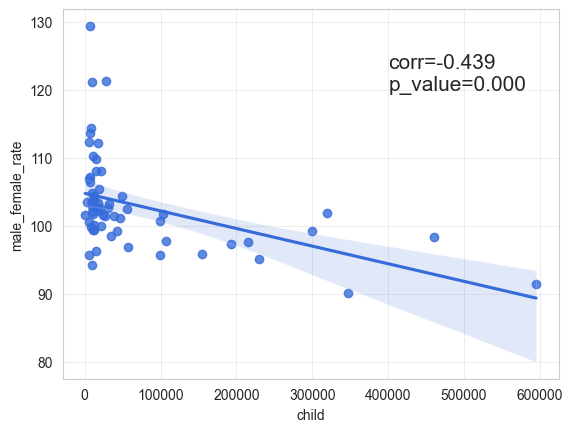

In [81]:
g=sns.regplot(data=compare_df, x="child", y="male_female_rate")
g.text(x=400_000, y=120, s=f"{corr=:.3f}\n{p_value=:.3f}", fontsize=15)

### Interpretation

Male to female ratio is moderately negatively related to child population in a county in New York State, and such correlation is statistically significant.